
# Week 1 – Tuesday Notebook
## What is sports analytics... really?

This notebook supports the first LinkedIn post in the series for **Introduction to Sports Analytics: Theory and Applications**.

It uses a **publicly available dataset** from FiveThirtyEight's NBA Elo project to show a simple sports-analytics workflow:
- load real sports data,
- inspect the structure,
- create a few basic descriptive metrics,
- and turn raw game results into initial performance insights.

The goal is not to build a complex model yet. The goal is to show how sports analytics begins with a good question and a clean, reproducible workflow.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)


## 1. Load a public sports dataset

In [2]:

url = "https://raw.githubusercontent.com/fivethirtyeight/data/master/nba-elo/nbaallelo.csv"
df = pd.read_csv(url)
df.head()


,gameorder,game_id,lg_id,_iscopy,year_id,date_game,seasongame,is_playoffs,team_id,fran_id,pts,elo_i,elo_n,win_equiv,opp_id,opp_fran,opp_pts,opp_elo_i,opp_elo_n,game_location,game_result,forecast,notes
0,1,194611010TRH,NBA,0,1947,11/1/1946,1,0,TRH,Huskies,66,1300.0000,1293.2767,40.294830,NYK,Knicks,68,1300.0000,1306.7233,H,L,0.640065,NaN
1,1,194611010TRH,NBA,1,1947,11/1/1946,1,0,NYK,Knicks,68,1300.0000,1306.7233,41.705170,TRH,Huskies,66,1300.0000,1293.2767,A,W,0.359935,NaN
2,2,194611020CHS,NBA,0,1947,11/2/1946,1,0,CHS,Stags,63,1300.0000,1309.6521,42.012257,NYK,Knicks,47,1306.7233,1297.0712,H,W,0.631101,NaN
3,2,194611020CHS,NBA,1,1947,11/2/1946,2,0,NYK,Knicks,47,1306.7233,1297.0712,40.692783,CHS,Stags,63,1300.0000,1309.6521,A,L,0.368899,NaN
4,3,194611020DTF,NBA,0,1947,11/2/1946,1,0,DTF,Falcons,33,1300.0000,1279.6189,38.864048,WSC,Capitols,50,1300.0000,1320.3811,H,L,0.640065,NaN



This dataset contains historical NBA game records and Elo ratings. For this introductory workflow, we will keep only a small subset of variables that are easy to interpret.


In [3]:

keep_cols = ['gameorder','year_id','fran_id','opp_fran','game_location','pts','opp_pts','elo_i','elo_n','win_equiv']
nba = df[keep_cols].copy()
nba['won'] = (nba['pts'] > nba['opp_pts']).astype(int)
nba['point_diff'] = nba['pts'] - nba['opp_pts']
nba = nba.rename(columns={
    'fran_id':'team',
    'opp_fran':'opponent',
    'game_location':'location',
    'pts':'team_points',
    'opp_pts':'opp_points',
    'elo_i':'elo_before',
    'elo_n':'elo_after'
})
nba.head()


,gameorder,year_id,team,opponent,location,team_points,opp_points,elo_before,elo_after,win_equiv,won,point_diff
0,1,1947,Huskies,Knicks,H,66,68,1300.0000,1293.2767,40.294830,0,-2
1,1,1947,Knicks,Huskies,A,68,66,1300.0000,1306.7233,41.705170,1,2
2,2,1947,Stags,Knicks,H,63,47,1300.0000,1309.6521,42.012257,1,16
3,2,1947,Knicks,Stags,A,47,63,1306.7233,1297.0712,40.692783,0,-16
4,3,1947,Falcons,Capitols,H,33,50,1300.0000,1279.6189,38.864048,0,-17


## 2. Explore the data

In [4]:

nba.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126314 entries, 0 to 126313
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   gameorder    126314 non-null  int64  
 1   year_id      126314 non-null  int64  
 2   team         126314 non-null  object 
 3   opponent     126314 non-null  object 
 4   location     126314 non-null  object 
 5   team_points  126314 non-null  int64  
 6   opp_points   126314 non-null  int64  
 7   elo_before   126314 non-null  float64
 8   elo_after    126314 non-null  float64
 9   win_equiv    126314 non-null  float64
 10  won          126314 non-null  int32  
 11  point_diff   126314 non-null  int64  
dtypes: float64(3), int32(1), int64(5), object(3)
memory usage: 11.1+ MB


In [5]:

nba.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gameorder,126314.0,NaN,NaN,NaN,31579.0,18231.927643,1.0,15790.0,31579.0,47368.0,63157.0
year_id,126314.0,NaN,NaN,NaN,1988.200374,17.582309,1947.0,1975.0,1990.0,2003.0,2015.0
team,126314,53,Lakers,6024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
opponent,126314,53,Lakers,6024,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,126314,3,H,63138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team_points,126314.0,NaN,NaN,NaN,102.729982,14.814845,0.0,93.0,103.0,112.0,186.0
opp_points,126314.0,NaN,NaN,NaN,102.729982,14.814845,0.0,93.0,103.0,112.0,186.0
elo_before,126314.0,NaN,NaN,NaN,1495.236055,112.139945,1091.6445,1417.237975,1500.94555,1576.06,1853.1045
elo_after,126314.0,NaN,NaN,NaN,1495.236055,112.461687,1085.7744,1416.9949,1500.9544,1576.291625,1853.1045
win_equiv,126314.0,NaN,NaN,NaN,41.707889,10.627332,10.152501,34.103035,42.113357,49.635328,71.112038



At this stage, a sports analyst is already doing meaningful work:
- understanding the unit of analysis (here, one team-game record),
- identifying useful variables,
- and creating derived metrics such as **won** and **point_diff**.


## 3. Focus on one season

In [6]:

latest_season = nba['year_id'].max()
season_df = nba[nba['year_id'] == latest_season].copy()
latest_season, season_df.shape


(2015, (2622, 12))

In [7]:

team_summary = (
    season_df.groupby('team')
    .agg(
        games=('team', 'size'),
        avg_points=('team_points', 'mean'),
        avg_opp_points=('opp_points', 'mean'),
        avg_point_diff=('point_diff', 'mean'),
        win_rate=('won', 'mean'),
        avg_elo_before=('elo_before', 'mean')
    )
    .reset_index()
    .sort_values(['win_rate', 'avg_point_diff'], ascending=False)
)
team_summary.head(10)


,team,games,avg_points,avg_opp_points,avg_point_diff,win_rate,avg_elo_before
28,Warriors,103,108.592233,98.961165,9.631068,0.805825,1723.327283
6,Hawks,98,101.806122,97.295918,4.510204,0.693878,1606.341571
2,Cavaliers,102,102.323529,97.941176,4.382353,0.656863,1568.234371
21,Rockets,99,104.656566,102.232323,2.424242,0.656566,1622.862546
4,Clippers,96,106.875000,101.052083,5.822917,0.656250,1657.552716
5,Grizzlies,93,97.892473,95.182796,2.709677,0.655914,1620.356600
23,Spurs,89,103.202247,97.460674,5.741573,0.651685,1676.631908
27,Trailblazers,87,102.275862,98.678161,3.597701,0.597701,1617.026179
1,Bulls,94,100.180851,97.127660,3.053191,0.595745,1571.535361
14,Mavericks,87,105.494253,103.000000,2.494253,0.586207,1598.599132


## 4. Create simple descriptive visuals

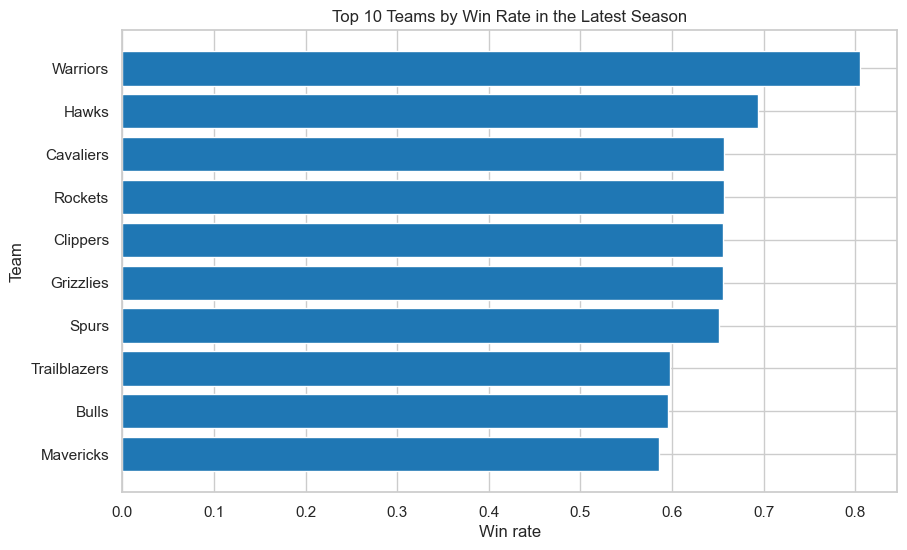

In [8]:

fig, ax = plt.subplots(figsize=(10, 6))
top10 = team_summary.head(10).sort_values('win_rate')
ax.barh(top10['team'], top10['win_rate'], color='#1f77b4')
ax.set_title('Top 10 Teams by Win Rate in the Latest Season')
ax.set_xlabel('Win rate')
ax.set_ylabel('Team')
plt.show()


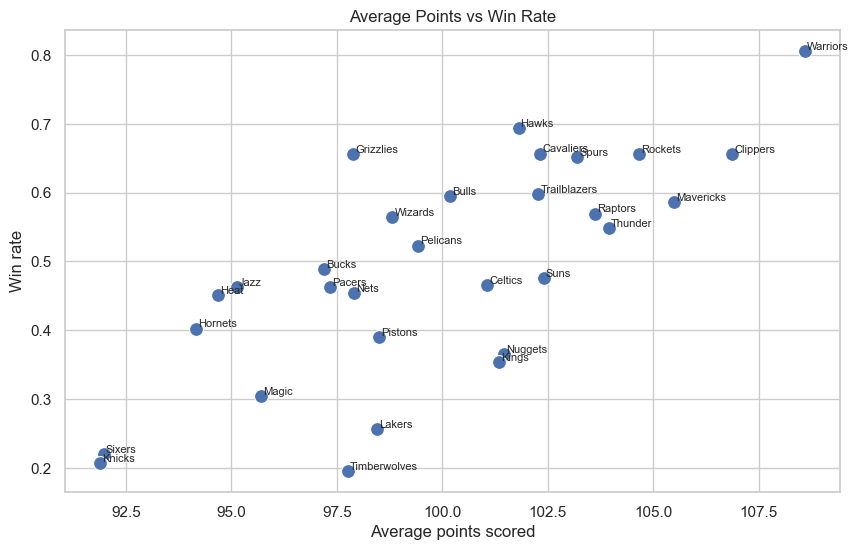

In [9]:

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=team_summary, x='avg_points', y='win_rate', s=100, ax=ax)
for _, row in team_summary.iterrows():
    ax.text(row['avg_points'] + 0.05, row['win_rate'] + 0.002, row['team'], fontsize=8)
ax.set_title('Average Points vs Win Rate')
ax.set_xlabel('Average points scored')
ax.set_ylabel('Win rate')
plt.show()


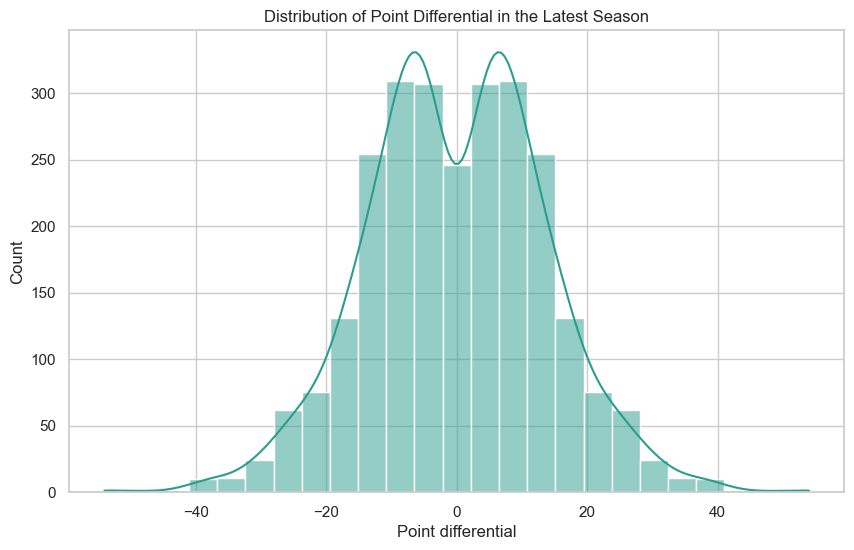

In [10]:

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(season_df['point_diff'], bins=25, kde=True, ax=ax, color='#2a9d8f')
ax.set_title('Distribution of Point Differential in the Latest Season')
ax.set_xlabel('Point differential')
plt.show()


## 5. Basic insights

In [11]:

correlation = team_summary[['avg_points', 'win_rate', 'avg_point_diff', 'avg_elo_before']].corr()
correlation


,avg_points,win_rate,avg_point_diff,avg_elo_before
avg_points,1.000000,0.725100,0.764664,0.789186
win_rate,0.725100,1.000000,0.975586,0.946674
avg_point_diff,0.764664,0.975586,1.000000,0.930378
avg_elo_before,0.789186,0.946674,0.930378,1.000000



Examples of beginner-friendly insights you can extract:
- Which teams score more on average?
- Which teams prevent opponents from scoring?
- How strongly is point differential associated with win rate?
- Which summary metric seems most aligned with winning?

This is the essence of an introductory sports-analytics workflow: start simple, compute clear metrics, visualize patterns, and ask better follow-up questions.


## 6. Save outputs for reuse

In [12]:

team_summary.to_csv('week1_tuesday_team_summary.csv', index=False)
season_df.to_csv('week1_tuesday_nba_sample.csv', index=False)
print(team_summary.head())


         team  games  avg_points  avg_opp_points  avg_point_diff  win_rate  \
28   Warriors    103  108.592233       98.961165        9.631068  0.805825   
6       Hawks     98  101.806122       97.295918        4.510204  0.693878   
2   Cavaliers    102  102.323529       97.941176        4.382353  0.656863   
21    Rockets     99  104.656566      102.232323        2.424242  0.656566   
4    Clippers     96  106.875000      101.052083        5.822917  0.656250   

    avg_elo_before  
28     1723.327283  
6      1606.341571  
2      1568.234371  
21     1622.862546  
4      1657.552716  
